['time', 'Altitude (GPS) (m)', 'Average fuel consumption (L/100km)', 'Average fuel consumption (Today) (L/100km)', 'Average fuel consumption (total) (L/100km)', 'Average fuel consumption (Week) (L/100km)', 'Average fuel consumption 10 sec (L/100km)', 'Average speed (km/h)', 'Average speed (GPS) (km/h)', 'Calculated instant fuel consumption (L/100km)', 'Calculated instant fuel rate (L/h)', 'Distance travelled (km)', 'Distance travelled (Today) (km)', 'Distance travelled (total) (km)', 'Distance travelled (Week) (km)', 'Engine coolant temperature (℃)', 'Engine RPM (rpm)', 'Engine RPM x1000 (rpm)', 'Fuel economizer (based on fuel system status and throttle position) ()', 'Fuel used (L)', 'Fuel used (Today) (L)', 'Fuel used (total) (L)', 'Fuel used (Week) (L)', 'Fuel used price ($)', 'Fuel used price (Today) ($)', 'Fuel used price (total) ($)', 'Fuel used price (Week) ($)', 'Instant engine power (based on fuel consumption) (hp)', 'MAF air flow rate (g/sec)', 'Oxygen sensor 1 Wide Range Equ

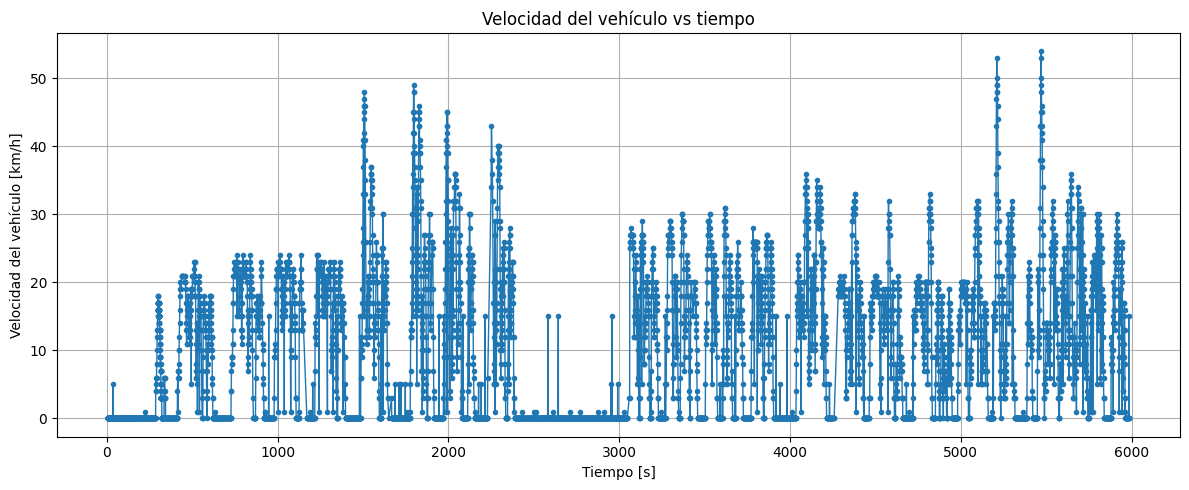

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. Ruta del archivo CSV
# ============================================================
filepath = r"14_05_26\odb_data.csv"   # cambia esto por el nombre real

# ============================================================
# 2. Leer CSV
# ============================================================
df = pd.read_csv(filepath)

# Limpiar nombres de columnas por si tienen espacios extra
df.columns = df.columns.str.strip()

print(df.columns.tolist())

# ============================================================
# 3. Convertir tiempo a datetime
# ============================================================
# El archivo tiene tiempo tipo: 11:37:08.516
fecha = "2026-05-14"
df["timestamp"] = pd.to_datetime(fecha + " " + df["time"])

# Unix en segundos
# df["time_unix_s"] = df["time"].astype("int64") / 1e9

# Unix en milisegundos
df["time_unix_ms"] = df["timestamp"].astype("int64") // 1_000

# Unix en nanosegundos
# df["time_unix_ns"] = df["time"].astype("int64")


print(df["time"])
# print(df["time_unix_s"])
print(df["time_unix_ms"])
# print(df["time_unix_ns"])
# df["time_unix"] = df["time"].to_timestamp()
# unix_s = df["time"].iloc[1].timestamp()
# unix_s
# unix_ms = int(unix_s * 1000)
# # unix_ns = int(unix_s * 1e9)

# # print("Datetime:", dt)
# print("Unix segundos:", unix_s)
# print("Unix milisegundos:", unix_ms)
# # print("Unix nanosegundos:", unix_ns)


# Crear tiempo relativo en segundos desde el inicio
# df["t"] = (df["time"] - df["time"].iloc[0]).dt.total_seconds()


# Crear tiempo relativo en segundos desde el inicio
df["t"] = (df["timestamp"] - df["timestamp"].iloc[0]).dt.total_seconds()

# ============================================================
# 4. Convertir velocidad a número
# ============================================================
speed_col = "Vehicle speed (km/h)"

df[speed_col] = pd.to_numeric(df[speed_col], errors="coerce")


# ============================================================
# 5. Eliminar filas sin velocidad válida
# ============================================================
df_speed = df.dropna(subset=["t", speed_col]).copy()


# ============================================================
# 6. Graficar velocidad del vehículo
# ============================================================
plt.figure(figsize=(12, 5))
plt.plot(df_speed["t"], df_speed[speed_col], marker=".", linewidth=1)

plt.xlabel("Tiempo [s]")
plt.ylabel("Velocidad del vehículo [km/h]")
plt.title("Velocidad del vehículo vs tiempo")
plt.grid(True)
plt.tight_layout()
plt.show()

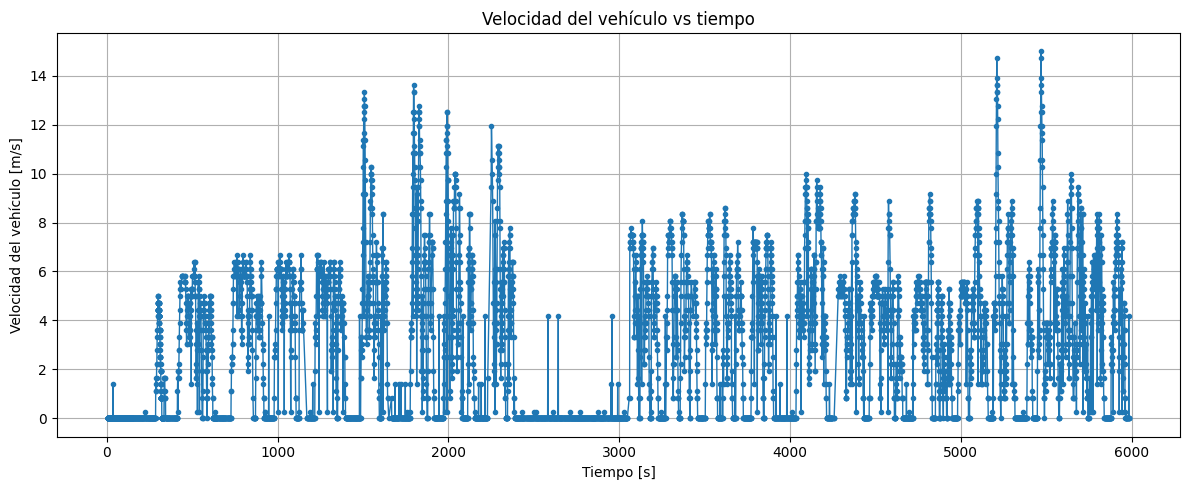

In [9]:
df_speed["vehicle_speed_ms"] = df_speed[speed_col] / 3.6

plt.figure(figsize=(12, 5))
plt.plot(df_speed["t"], df_speed["vehicle_speed_ms"], marker=".", linewidth=1)

plt.xlabel("Tiempo [s]")
plt.ylabel("Velocidad del vehículo [m/s]")
plt.title("Velocidad del vehículo vs tiempo")
plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
df_speed.head()

,time,Altitude (GPS) (m),Average fuel consumption (L/100km),Average fuel consumption (Today) (L/100km),Average fuel consumption (total) (L/100km),Average fuel consumption (Week) (L/100km),Average fuel consumption 10 sec (L/100km),Average speed (km/h),Average speed (GPS) (km/h),Calculated instant fuel consumption (L/100km),...,Throttle position (%),Vehicle acceleration (g),Vehicle speed (km/h),Latitude,Longtitude,Unnamed: 38,timestamp,time_unix_ms,t,vehicle_speed_ms
1,11:37:08.516,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,17.647059,NaN,0.0,-12.100222,-77.023612,NaN,2026-05-14 11:37:08.516,1778758628516,7.525,0.0
2,11:37:08.670,NaN,NaN,21.405951,21.405951,21.405951,NaN,0.0,NaN,NaN,...,17.647059,NaN,0.0,-12.100222,-77.023612,NaN,2026-05-14 11:37:08.670,1778758628670,7.679,0.0
3,11:37:08.825,NaN,NaN,21.407535,21.407535,21.407535,NaN,0.0,NaN,NaN,...,17.647059,NaN,0.0,-12.100222,-77.023612,NaN,2026-05-14 11:37:08.825,1778758628825,7.834,0.0
4,11:37:08.972,NaN,NaN,21.409043,21.409043,21.409043,NaN,0.0,NaN,NaN,...,17.647059,NaN,0.0,-12.100222,-77.023612,NaN,2026-05-14 11:37:08.972,1778758628972,7.981,0.0
5,11:37:09.115,NaN,NaN,21.410551,21.410551,21.410551,NaN,0.0,NaN,NaN,...,17.647059,0.0,0.0,-12.100222,-77.023612,NaN,2026-05-14 11:37:09.115,1778758629115,8.124,0.0


In [11]:
df_speed["dt"] = df_speed["time_unix_ms"].diff() / 1_000
df_speed.head()

,time,Altitude (GPS) (m),Average fuel consumption (L/100km),Average fuel consumption (Today) (L/100km),Average fuel consumption (total) (L/100km),Average fuel consumption (Week) (L/100km),Average fuel consumption 10 sec (L/100km),Average speed (km/h),Average speed (GPS) (km/h),Calculated instant fuel consumption (L/100km),...,Vehicle acceleration (g),Vehicle speed (km/h),Latitude,Longtitude,Unnamed: 38,timestamp,time_unix_ms,t,vehicle_speed_ms,dt
1,11:37:08.516,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.0,-12.100222,-77.023612,NaN,2026-05-14 11:37:08.516,1778758628516,7.525,0.0,NaN
2,11:37:08.670,NaN,NaN,21.405951,21.405951,21.405951,NaN,0.0,NaN,NaN,...,NaN,0.0,-12.100222,-77.023612,NaN,2026-05-14 11:37:08.670,1778758628670,7.679,0.0,0.154
3,11:37:08.825,NaN,NaN,21.407535,21.407535,21.407535,NaN,0.0,NaN,NaN,...,NaN,0.0,-12.100222,-77.023612,NaN,2026-05-14 11:37:08.825,1778758628825,7.834,0.0,0.155
4,11:37:08.972,NaN,NaN,21.409043,21.409043,21.409043,NaN,0.0,NaN,NaN,...,NaN,0.0,-12.100222,-77.023612,NaN,2026-05-14 11:37:08.972,1778758628972,7.981,0.0,0.147
5,11:37:09.115,NaN,NaN,21.410551,21.410551,21.410551,NaN,0.0,NaN,NaN,...,0.0,0.0,-12.100222,-77.023612,NaN,2026-05-14 11:37:09.115,1778758629115,8.124,0.0,0.143


In [12]:
df_speed.to_csv(r'14_05_26\csv_output\obd_data_all_times.csv', index=False)
df_speed

,time,Altitude (GPS) (m),Average fuel consumption (L/100km),Average fuel consumption (Today) (L/100km),Average fuel consumption (total) (L/100km),Average fuel consumption (Week) (L/100km),Average fuel consumption 10 sec (L/100km),Average speed (km/h),Average speed (GPS) (km/h),Calculated instant fuel consumption (L/100km),...,Vehicle acceleration (g),Vehicle speed (km/h),Latitude,Longtitude,Unnamed: 38,timestamp,time_unix_ms,t,vehicle_speed_ms,dt
1,11:37:08.516,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.0,-12.100222,-77.023612,NaN,2026-05-14 11:37:08.516,1778758628516,7.525,0.000000,NaN
2,11:37:08.670,NaN,NaN,21.405951,21.405951,21.405951,NaN,0.000000,NaN,NaN,...,NaN,0.0,-12.100222,-77.023612,NaN,2026-05-14 11:37:08.670,1778758628670,7.679,0.000000,0.154
3,11:37:08.825,NaN,NaN,21.407535,21.407535,21.407535,NaN,0.000000,NaN,NaN,...,NaN,0.0,-12.100222,-77.023612,NaN,2026-05-14 11:37:08.825,1778758628825,7.834,0.000000,0.155
4,11:37:08.972,NaN,NaN,21.409043,21.409043,21.409043,NaN,0.000000,NaN,NaN,...,NaN,0.0,-12.100222,-77.023612,NaN,2026-05-14 11:37:08.972,1778758628972,7.981,0.000000,0.147
5,11:37:09.115,NaN,NaN,21.410551,21.410551,21.410551,NaN,0.000000,NaN,NaN,...,0.00000,0.0,-12.100222,-77.023612,NaN,2026-05-14 11:37:09.115,1778758629115,8.124,0.000000,0.143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24149,13:16:41.897,NaN,NaN,NaN,NaN,NaN,NaN,10.227684,NaN,NaN,...,0.00000,0.0,-12.096945,-77.023221,NaN,2026-05-14 13:16:41.897,1778764601897,5980.906,0.000000,2.174
24155,13:16:42.530,NaN,NaN,NaN,NaN,NaN,NaN,10.226584,NaN,NaN,...,0.00000,0.0,-12.104030,-77.020096,NaN,2026-05-14 13:16:42.530,1778764602530,5981.539,0.000000,0.633
24161,13:16:43.158,NaN,NaN,NaN,NaN,NaN,NaN,10.227093,NaN,4.123195,...,0.07321,15.0,-12.104055,-77.020027,NaN,2026-05-14 13:16:43.158,1778764603158,5982.167,4.166667,0.628
24165,13:16:43.845,NaN,NaN,NaN,NaN,NaN,NaN,10.225903,NaN,NaN,...,NaN,0.0,-12.104055,-77.020027,NaN,2026-05-14 13:16:43.845,1778764603845,5982.854,0.000000,0.687


In [13]:
import numpy as np
import pandas as pd

# Asegurar que dt sea numérico
df_speed["dt"] = pd.to_numeric(df_speed["dt"], errors="coerce")

# Quitar NaN y valores no válidos
dt_valid = df_speed["dt"].dropna()
dt_valid = dt_valid[dt_valid > 0]

# Frecuencia instantánea por muestra
df_speed["fs_inst_Hz"] = 1 / df_speed["dt"]

# Frecuencia promedio
fs_mean = 1 / dt_valid.mean()

# Frecuencia mediana, más robusta ante saltos grandes
fs_median = 1 / dt_valid.median()

print("dt promedio:", dt_valid.mean(), "s")
print("dt mediana :", dt_valid.median(), "s")
print("Frecuencia promedio:", fs_mean, "Hz")
print("Frecuencia mediana :", fs_median, "Hz")

dt promedio: 0.9206439685718688 s
dt mediana : 0.811 s
Frecuencia promedio: 1.0861962214896501 Hz
Frecuencia mediana : 1.2330456226880393 Hz
